In [1]:
import json
import pandas as pd
from collections import Counter

with open("labeled_reviews.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(len(data))

300


In [2]:
all_labels = []
review_label_pairs = []

for task in data:

    review_id = task.get("id")

    annotations = task.get("annotations", [])

    for ann in annotations:

        for result in ann.get("result", []):

            labels = result.get("value", {}).get("labels", [])

            for label in labels:
                all_labels.append(label)
                review_label_pairs.append((review_id, label))

In [3]:
label_counts = Counter(all_labels)

label_df = pd.DataFrame(
    label_counts.items(),
    columns=["label", "num_spans"]
).sort_values("num_spans", ascending=False)

label_df

,label,num_spans
14,CARDS_POS,194
0,SUPPORT_NEG,158
3,SUPPORT_POS,113
6,CARDS_NEG,96
16,OFFICE_NEG,79
5,OTHER_NEG,72
7,DIGITAL_NEG,48
17,PAYMENTS_NEG,39
2,FRAUD_NEG,37
8,FEES_NEG,36


In [4]:
review_label_df = pd.DataFrame(
    review_label_pairs,
    columns=["review_id", "label"]
)

unique_review_counts = (
    review_label_df
    .drop_duplicates()
    .groupby("label")
    .size()
    .reset_index(name="num_reviews")
)

unique_review_counts = unique_review_counts.sort_values(
    "num_reviews",
    ascending=False
)

unique_review_counts

,label,num_reviews
3,CARDS_POS,100
21,SUPPORT_NEG,94
2,CARDS_NEG,70
22,SUPPORT_POS,69
16,OTHER_NEG,55
14,OFFICE_NEG,42
5,DIGITAL_NEG,37
18,PAYMENTS_NEG,26
7,FEES_NEG,24
9,FRAUD_NEG,22


In [5]:
stats_df = label_df.merge(
    unique_review_counts,
    on="label",
    how="outer"
).fillna(0)

stats_df = stats_df.sort_values(
    "num_spans",
    ascending=False
)

stats_df

,label,num_spans,num_reviews
3,CARDS_POS,194,100
21,SUPPORT_NEG,158,94
22,SUPPORT_POS,113,69
2,CARDS_NEG,96,70
14,OFFICE_NEG,79,42
16,OTHER_NEG,72,55
5,DIGITAL_NEG,48,37
18,PAYMENTS_NEG,39,26
9,FRAUD_NEG,37,22
7,FEES_NEG,36,24


In [6]:
ALL_LABELS = [
    "CARDS_POS", "CARDS_NEG",
    "DIGITAL_POS", "DIGITAL_NEG",
    "SUPPORT_POS", "SUPPORT_NEG",
    "PAYMENTS_POS", "PAYMENTS_NEG",
    "CREDITS_POS", "CREDITS_NEG",
    "FEES_POS", "FEES_NEG",
    "OFFICE_POS", "OFFICE_NEG",
    "ATM_POS", "ATM_NEG",
    "FRAUD_POS", "FRAUD_NEG",
    "INSURANCE_POS", "INSURANCE_NEG",
    "INVESTMENTS_POS", "INVESTMENTS_NEG",
    "PREMIUM_POS", "PREMIUM_NEG",
    "OTHER_POS", "OTHER_NEG"
]

In [7]:
existing = set(stats_df["label"])

missing = [
    label
    for label in ALL_LABELS
    if label not in existing
]

missing

['PAYMENTS_POS', 'CREDITS_POS', 'FRAUD_POS']

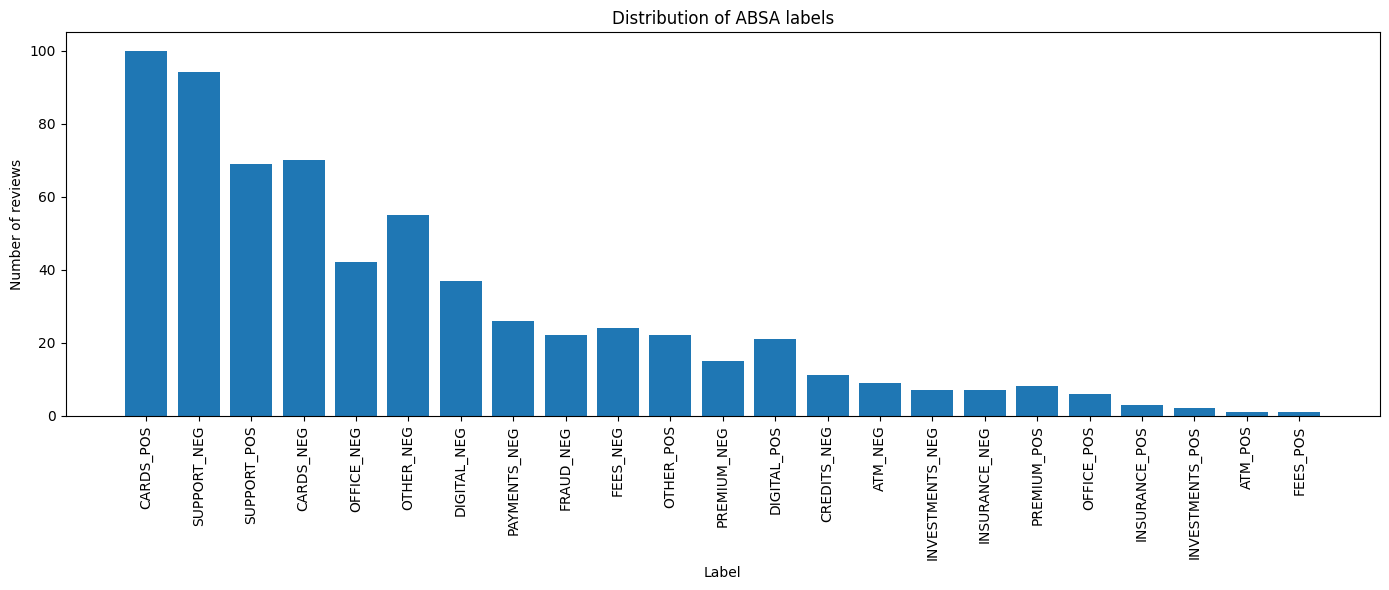

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.bar(stats_df["label"], stats_df["num_reviews"])

plt.xticks(rotation=90)

plt.xlabel("Label")
plt.ylabel("Number of reviews")
plt.title("Distribution of ABSA labels")

plt.tight_layout()

plt.show()

### После попытки добавить реальные отзывы из датасета, чтобы поправить смещение


In [9]:
with open("labeled_reviews_with_additional.json", "r", encoding="utf-8") as f:
    data_all = json.load(f)

print(len(data_all))

311


In [10]:
all_labels_with_additional = []
review_label_pairs_with_additional = []

for task in data_all:

    review_id = task.get("id")

    annotations = task.get("annotations", [])

    for ann in annotations:

        for result in ann.get("result", []):

            labels = result.get("value", {}).get("labels", [])

            for label in labels:
                all_labels_with_additional.append(label)
                review_label_pairs_with_additional.append((review_id, label))

In [11]:
label_counts_all = Counter(all_labels_with_additional)

label_df_all = pd.DataFrame(
    label_counts_all.items(),
    columns=["label", "num_spans"]
).sort_values("num_spans", ascending=False)

label_df_all

,label,num_spans
14,CARDS_POS,195
0,SUPPORT_NEG,161
3,SUPPORT_POS,114
6,CARDS_NEG,96
16,OFFICE_NEG,81
5,OTHER_NEG,73
7,DIGITAL_NEG,48
2,FRAUD_NEG,39
17,PAYMENTS_NEG,39
8,FEES_NEG,37


In [12]:
review_label_df_all = pd.DataFrame(
    review_label_pairs_with_additional,
    columns=["review_id", "label"]
)

unique_review_counts_all = (
    review_label_df_all
    .drop_duplicates()
    .groupby("label")
    .size()
    .reset_index(name="num_reviews")
)

unique_review_counts_all = unique_review_counts_all.sort_values(
    "num_reviews",
    ascending=False
)

unique_review_counts_all

,label,num_reviews
3,CARDS_POS,101
21,SUPPORT_NEG,97
2,CARDS_NEG,70
22,SUPPORT_POS,70
16,OTHER_NEG,56
14,OFFICE_NEG,44
5,DIGITAL_NEG,37
18,PAYMENTS_NEG,26
7,FEES_NEG,25
9,FRAUD_NEG,24


In [13]:
stats_df_all = label_df_all.merge(
    unique_review_counts_all,
    on="label",
    how="outer"
).fillna(0)

stats_df_all = stats_df_all.sort_values(
    "num_spans",
    ascending=False
)

stats_df_all

,label,num_spans,num_reviews
3,CARDS_POS,195,101
21,SUPPORT_NEG,161,97
22,SUPPORT_POS,114,70
2,CARDS_NEG,96,70
14,OFFICE_NEG,81,44
16,OTHER_NEG,73,56
5,DIGITAL_NEG,48,37
18,PAYMENTS_NEG,39,26
9,FRAUD_NEG,39,24
7,FEES_NEG,37,25


In [14]:
existing = set(stats_df_all["label"])

missing = [
    label
    for label in ALL_LABELS
    if label not in existing
]

missing

['PAYMENTS_POS', 'CREDITS_POS', 'FRAUD_POS']